# Раздел 1. Основы теории вероятностей
---

## Тема 3. Формула полной вероятности
---

In [1]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt

### Задача
> В одной урне $15$ белых и $5$ чёрных шаров, а в другой — $6$ белых и $1$ чёрный. Из первой урны случайным образом вынимают $3$ шара и опускают во вторую урну. После этого из второй урны также случайно вынимают $1$ шар. Найти вероятность того, что шар, вынутый из второй урны, — белый.

Опыт распадается на два этапа: сначала во вторую урну попадает какой-то набор шаров, и лишь на его фоне вынимается последний шар. Состав второй урны заранее неизвестен — значит, работает **формула полной вероятности**.

**Гипотезы.** $A_k$ — среди трёх перенесённых шаров ровно $k$ белых, $k = 0, 1, 2, 3$. Шары вынимают без возврата и порядок не важен, поэтому число способов — **сочетания**:

$P(A_k) = \frac{C_{15}^{k} \cdot C_{5}^{\,3-k}}{C_{20}^{3}}, \qquad C_{20}^{3} = 1140$

$P(A_0) = \frac{C_5^3}{1140} = \frac{10}{1140}, \quad P(A_1) = \frac{C_{15}^1 C_5^2}{1140} = \frac{150}{1140}, \quad P(A_2) = \frac{C_{15}^2 C_5^1}{1140} = \frac{525}{1140}, \quad P(A_3) = \frac{C_{15}^3}{1140} = \frac{455}{1140}$

Сумма числителей $10 + 150 + 525 + 455 = 1140$, т.е. $\sum P(A_k) = 1$ — гипотезы образуют полную группу.

**Условные вероятности.** После переноса во второй урне стало $7 + 3 = 10$ шаров, из них белых $6 + k$:

$P_{A_k}(F) = \frac{6 + k}{10}$

**Формула полной вероятности (1.31):**

$P(F) = \sum_{k=0}^{3} P(A_k)\, P_{A_k}(F) = \frac{10 \cdot 6 + 150 \cdot 7 + 525 \cdot 8 + 455 \cdot 9}{1140 \cdot 10} = \frac{9405}{11400} = \frac{33}{40} = 0{,}825$

In [2]:
W1, B1 = 15, 5      # первая урна: белые и чёрные
W2, B2 = 6, 1       # вторая урна до переноса
m = 3               # сколько шаров переносим

n_urn = sc.comb(W1 + B1, m)          # все способы вынуть 3 шара из первой урны
P_white = 0
for k in range(m + 1):               # k — число белых среди перенесённых
    P_k = sc.comb(W1, k) * sc.comb(B1, m - k) / n_urn   # вероятность гипотезы
    P_kF = (W2 + k) / (W2 + B2 + m)                     # условная вероятность белого
    print(f"k = {k}:  P(A_k) = {P_k:.4f},  P_A(F) = {P_kF:.4f}")
    P_white += P_k * P_kF

round(P_white, 4)

k = 0:  P(A_k) = 0.0088,  P_A(F) = 0.6000
k = 1:  P(A_k) = 0.1316,  P_A(F) = 0.7000
k = 2:  P(A_k) = 0.4605,  P_A(F) = 0.8000
k = 3:  P(A_k) = 0.3991,  P_A(F) = 0.9000


np.float64(0.825)

### Моделирование

Проверим ответ прямым экспериментом. Один опыт: из первой урны без возврата вынимаем $3$ шара, добавляем их во вторую и вынимаем оттуда один шар. Белый шар кодируем единицей, чёрный — нулём, тогда доля белых — это просто среднее по всем опытам. Повторим опыт $100\,000$ раз.

In [3]:
n = 100000
rng = np.random.default_rng()

urn1 = np.array([1] * W1 + [0] * B1)    # первая урна: 1 — белый, 0 — чёрный
base2 = np.array([1] * W2 + [0] * B2)   # вторая урна до переноса

res = np.empty(n, dtype=int)
for i in range(n):
    transfer = rng.choice(urn1, size=m, replace=False)  # переносим 3 шара без возврата
    urn2 = np.concatenate([base2, transfer])            # вторая урна после переноса
    res[i] = rng.choice(urn2)                           # вынимаем один шар

print("белых:", res.sum(), "из", n)
round(res.mean(), 4)

белых: 82374 из 100000


np.float64(0.8237)

Частота близка к $0{,}825$. С ростом числа опытов она всё точнее приближается к теоретической вероятности:

In [4]:
for n_i in [100, 1000, 10000, 100000]:
    print(f"n = {n_i}:  m/n = {res[:n_i].mean()}")

n = 100:  m/n = 0.81
n = 1000:  m/n = 0.825
n = 10000:  m/n = 0.8251
n = 100000:  m/n = 0.82374


### Иллюстрация

Нарисуем накопленную частоту: после каждого опыта пересчитываем долю белых среди всех проведённых опытов.

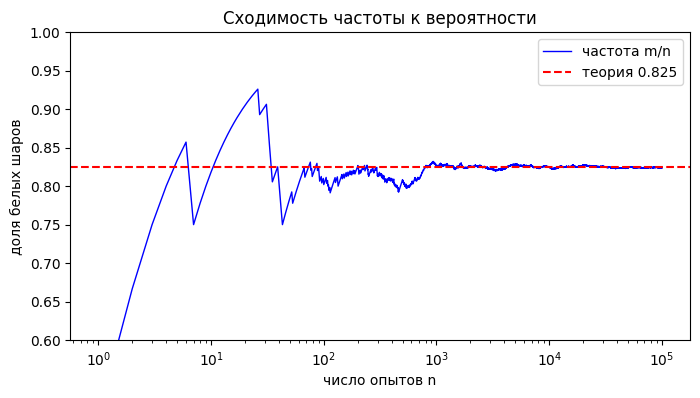

In [5]:
run = np.cumsum(res) / np.arange(1, n + 1)  # накопленная частота

plt.figure(figsize=(8, 4))
plt.plot(run, color="blue", lw=1, label="частота m/n")
plt.axhline(P_white, color="red", ls="--", label=f"теория {round(P_white, 4)}")
plt.xscale("log")  # по горизонтали логарифмический масштаб: видно и начало, и хвост
plt.xlabel("число опытов n")
plt.ylabel("доля белых шаров")
plt.ylim(0.6, 1.0)
plt.title("Сходимость частоты к вероятности")
plt.legend()
plt.show()

Кривая быстро «прилипает» к теоретической прямой — моделирование подтверждает расчёт.

**Ответ:** $P(F) = \frac{33}{40} = 0{,}825$.